## **0. Settings**

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from src.training import model
from src.explainability import attribution, visualizer

e:\Projects\AI Content Detection\venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


## **2. Load Model & Tokenizer**

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('Qualcomm-AI-Research/BamiBERT')

model = model.AIContentModel(model_name='Qualcomm-AI-Research/BamiBERT', num_classes=2)
checkpoint = torch.load('../models/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

e:\Projects\AI Content Detection\venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of RobertaModel were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AIContentModel(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(20481, 768, padding_idx=1)
      (position_embeddings): Embedding(2050, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerN

## **3. Load Test Data & Explainer**

In [4]:
test_df = pd.read_csv('../data/evaluated/test_df_evaluated.csv')
explainer = attribution.AttributionExplainer(model, tokenizer, device, max_length=512)

## **4. Explain 1 Sample**

In [5]:
torch.cuda.empty_cache()

sample = test_df[(test_df['label'] == 1) & (test_df['prediction'] == 1)].iloc[0]
result = explainer.explain(sample['cleaned_text'], target_label=1, n_steps=5)

print(f'Text: {sample["cleaned_text"][:150]}...')
print(f"True Label: AI | Predicted: {'AI' if result['predicted_label'] == 1 else 'Human'} (prob = {result['pred_prob']:.3f})")

Text: Theo nhiều nguồn tin, Samsung đang chuẩn bị ra mắt cùng lúc hai mẫu điện thoại gập dạng sách: **Galaxy Z Fold 8** và một phiên bản hoàn toàn mới mang ...
True Label: AI | Predicted: AI (prob = 0.999)


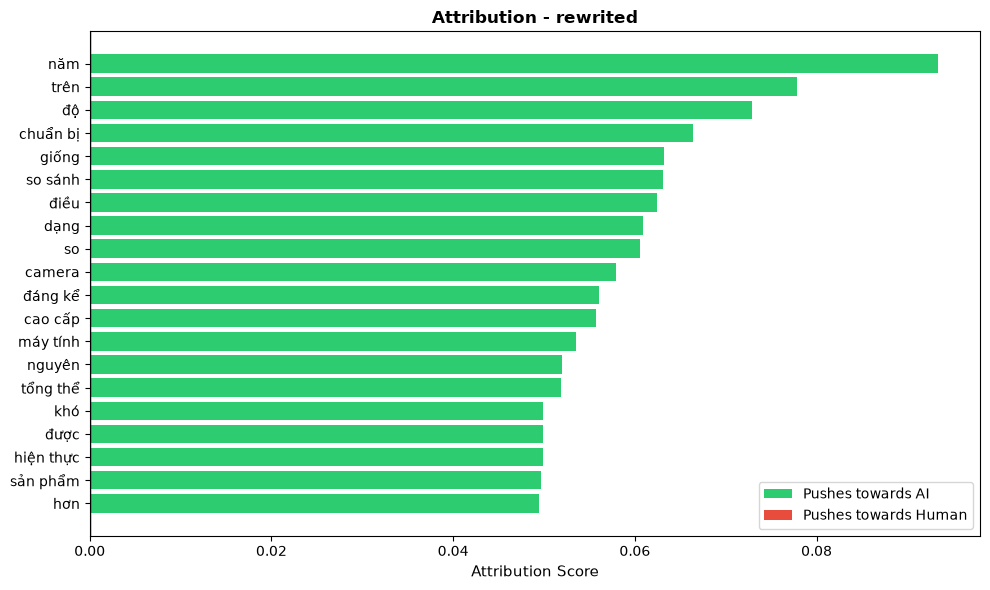

In [6]:
filtered_words, filtered_scores = visualizer.filter_punct(result['tokens'], result['scores'])
result_filtered = {**result, 'tokens': list(filtered_words), 'scores': np.array(filtered_scores)}

top = explainer.top_tokens(result_filtered, k=20, dedupe='mean')
words_plot, scores_plot = zip(*top) if top else ([], [])

save_path = '../figures/explainability/token_attribution.png'

visualizer.plot_token_attribution(list(words_plot), np.array(scores_plot),
                                   title=f"Attribution - {sample['generated_type']}", save_path=save_path)

In [7]:
# Visualize highlight text
pred_str = 'AI' if result['predicted_label'] == 1 else 'Human'
true_str = 'AI' if sample['label'] == 1 else 'Human'

visualizer.highlight_text(
    result['tokens'],
    result['scores'],
    title=f"Attribution - {sample['generated_type']}",
    pred_label=pred_str,
    pred_prob=result['pred_prob'],
    true_label=true_str
)

[human] prob=0.973 | text: Nga tự hào với tên lửa Avangard tốc độ khủng Mach 27, Trung Quốc dẫn đầu số lượn...
[rewrited] prob=0.999 | text: OpenAI GPT-4 hiện là một trong những mô hình ngôn ngữ lớn (LLM) phổ biến và mạnh...
[generated] prob=0.999 | text: Trong vài năm gần đây, một kiến trúc dữ liệu mới đã nổi lên, được gọi là Data La...


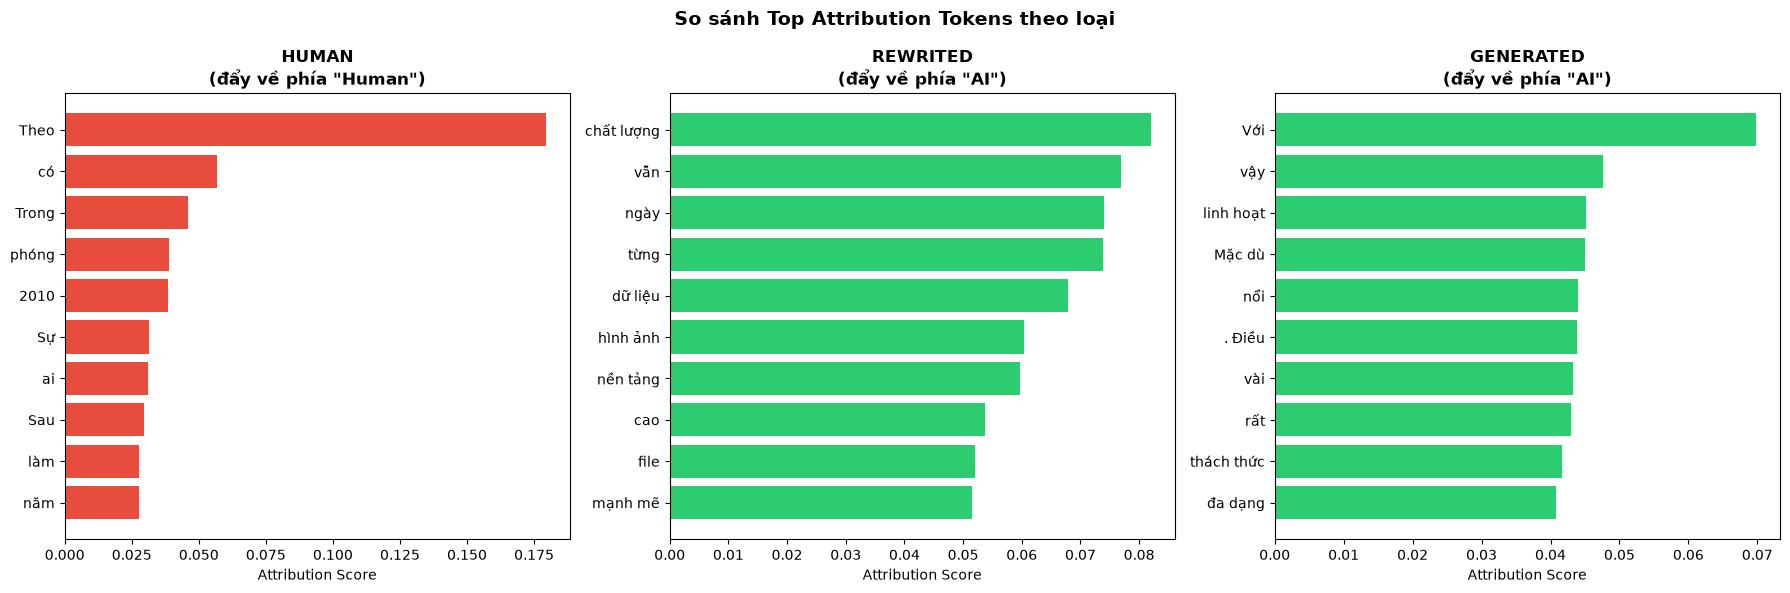

In [8]:
# Bar chart top k
top_tokens_per_type = {}
gen_types = ['human', 'rewrited', 'generated']

for gen_type in gen_types:
    subset = test_df[test_df['generated_type'] == gen_type]

    subset = subset[subset['prediction'] == subset['label']]
    sample = subset.iloc[len(subset) // 2]

    target = int(sample['label'])

    result = explainer.explain(sample['cleaned_text'], target_label=target, n_steps=5) 
    
    filtered_words, filtered_scores = visualizer.filter_punct(result['tokens'], result['scores'])
    result_filtered = {**result, 'tokens': list(filtered_words), 'scores': np.array(filtered_scores)}

    top_tokens_per_type[gen_type] = explainer.top_tokens(result_filtered, k=10, dedupe='mean')
    print(f"[{gen_type}] prob={result['pred_prob']:.3f} | text: {sample['cleaned_text'][:80]}...")

save_path = '../figures/explainability/top_attribution_tokens.png'

visualizer.plot_top_tokens_by_type(top_tokens_per_type, save_path=save_path)